# House Price Prediction

## Objective

Predict the median house value using demographic and geographical features from the California Housing dataset.

## Workflow

1. Load Dataset
2. Explore Dataset
3. Data Cleaning
4. Feature Engineering
5. Model Training
6. Model Evaluation

## Imports

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



## Load Dataset

In [7]:

from sklearn.datasets import fetch_california_housing

In [8]:
housing=fetch_california_housing()

In [9]:
df=pd.DataFrame(housing.data,columns=housing.feature_names)

In [10]:
df['MedHouseVal']=housing.target

# Dataset Features

The California Housing dataset contains demographic, housing, and geographical information collected from different districts in California. The goal is to predict the **median house value (MedHouseVal)** using the remaining features.

| Feature | Description |
|---------|-------------|
| **MedInc** | Median income of households in the district (tens of thousands of dollars). |
| **HouseAge** | Median age of houses in the district (years). |
| **AveRooms** | Average number of rooms per household. |
| **AveBedrms** | Average number of bedrooms per household. |
| **Population** | Total population in the district. |
| **AveOccup** | Average number of occupants per household. |
| **Latitude** | Geographic latitude of the district. |
| **Longitude** | Geographic longitude of the district. |
| **MedHouseVal** *(Target)* | Median house value in the district (hundreds of thousands of dollars). |

In [6]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [7]:
df.shape

(20640, 9)

In [8]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [10]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Observations

- Dataset contains 20,640 rows and 9 columns.
- All features are numerical (float64).
- No missing values are present.
- The target variable is MedHouseVal.
- No categorical features are present.
- Some columns (e.g., AveRooms and AveOccup) appear to contain extreme values that may need further investigation.

##  Missing Values

In [11]:

df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [12]:
## Duplicate Rows
df.duplicated().sum()

np.int64(0)

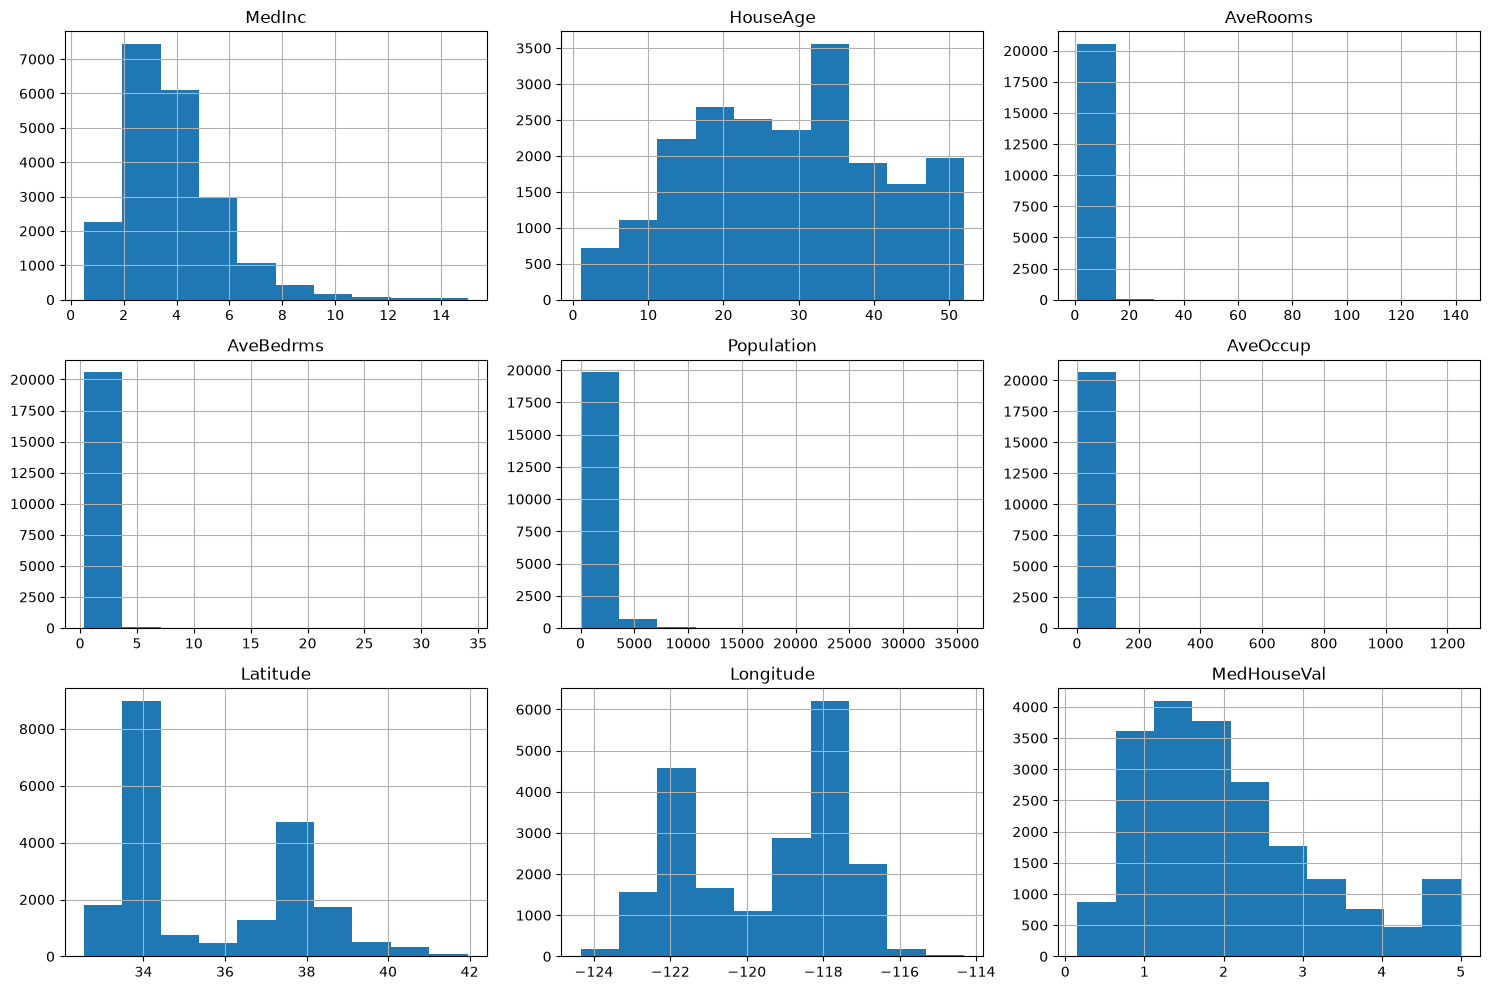

In [13]:
## Feature Distribution
df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

## Observations

- Most numerical features are right-skewed.
- Features such as AveRooms, AveBedrms, Population, and AveOccup contain extreme values that may represent outliers.
- HouseAge appears to be capped at 52 years.
- Latitude and Longitude show bimodal distributions, indicating houses are concentrated in two geographical regions.
- The target variable (MedHouseVal) is not normally distributed and appears to have an upper limit around 5.

## Correalation Analysis

In [14]:
correlation=df.corr()

correlation['MedHouseVal'].sort_values(ascending=False)


MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

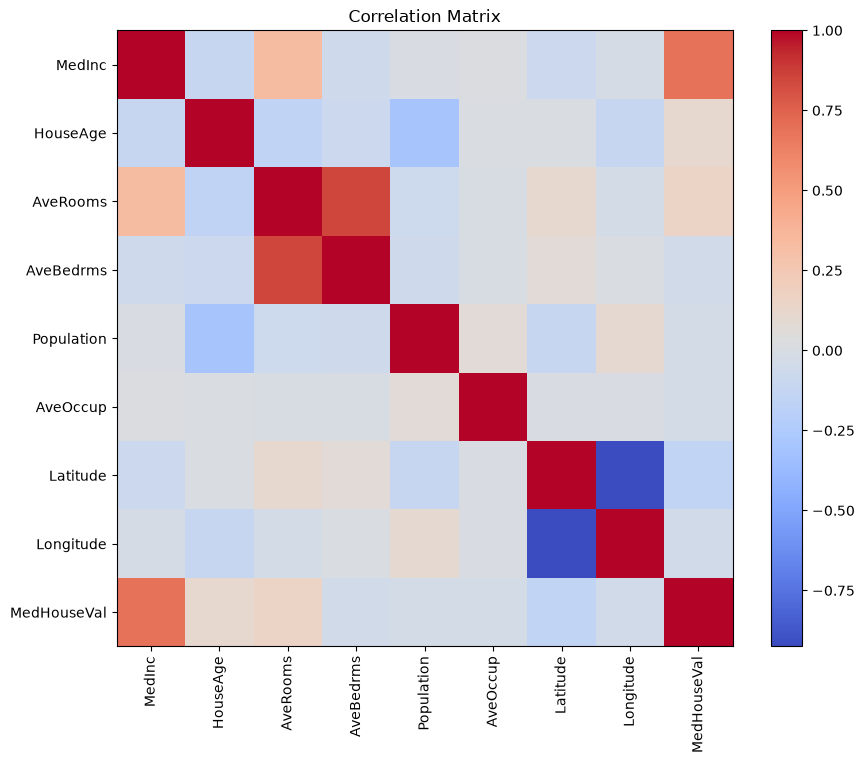

In [15]:
plt.figure(figsize=(10,8))
plt.imshow(correlation,cmap='coolwarm',interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(correlation.columns)),correlation.columns,rotation=90)
plt.yticks(range(len(correlation.columns)),correlation.columns)
plt.title("Correlation Matrix")
plt.show()

## Observations

- MedInc has the strongest positive correlation with the target (MedHouseVal), suggesting it may be one of the most important predictors.
- AveRooms has a weak positive correlation with house prices.
- Latitude and Longitude show weak negative correlations with the target.
- Population and AveOccup exhibit very little linear relationship with house prices.
- AveRooms and AveBedrms are highly positively correlated, indicating potential multicollinearity.

## Key Findings

- The dataset contains 20,640 rows and 9 numerical columns.
- No missing values or duplicate rows were found.
- Several features show right-skewed distributions and potential outliers.
- MedInc has the strongest positive linear relationship with house prices (0.688).
- Most other features have weak linear correlations with the target.
- Outliers will be investigated further rather than removed immediately.

## Train-Test Split

In [11]:
from sklearn.model_selection import train_test_split

X=df.drop('MedHouseVal',axis=1)
y=df['MedHouseVal']

X_train,X_test,y_train,y_test=train_test_split(X,
                                               y,
                                               test_size=0.2,
                                               random_state=42
                                               )


## Feature Scaling

In [18]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

In [20]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [25]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()

model.fit(X_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.85, 0.12,-0.29,...,-0.04,-0.9 ,-0.87]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.072
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](8,)","[182.86,175.83,145. ,...,104.18, 36.96, 27.94]"


In [26]:
model.coef_

array([ 0.85438303,  0.12254624, -0.29441013,  0.33925949, -0.00230772,
       -0.0408291 , -0.89692888, -0.86984178])

In [27]:
model.intercept_


np.float64(2.071946937378881)

## Model Evaluation

In [28]:
y_pred=model.predict(X_test_scaled)

In [31]:
print(y_pred[:10])
print(y_test[:10])

[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]
20046    0.47700
3024     0.45800
15663    5.00001
20484    2.18600
9814     2.78000
13311    1.58700
7113     1.98200
7668     1.57500
18246    3.40000
5723     4.46600
Name: MedHouseVal, dtype: float64


In [11]:
from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [32]:
mae=mean_absolute_error(y_test,y_pred)

mse=mean_squared_error(y_test,y_pred)

rmse=np.sqrt(mse)

r2=r2_score(y_test,y_pred)



In [33]:
print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R²:",r2)


MAE: 0.5332001304956565
MSE: 0.5558915986952444
RMSE: 0.7455813830127764
R²: 0.5757877060324508


## Observations

- On average, the model's predictions differ from the actual house prices by approximately **0.53** (≈ **$53,300**).
- RMSE is higher than MAE, indicating that larger prediction errors are penalized more heavily.
- The Linear Regression model explains approximately **57.6% of the variation** in house prices.
- The model serves as a strong baseline for comparison with more advanced algorithms such as Random Forest and XGBoost.

# Conclusion

In this project, we built a complete baseline machine learning pipeline for predicting California housing prices.

The workflow included:

- Data loading
- Exploratory Data Analysis (EDA)
- Missing value and duplicate analysis
- Correlation analysis
- Train-test splitting
- Feature scaling
- Training a Linear Regression model
- Model evaluation using MAE, MSE, RMSE, and R²

The baseline Linear Regression model achieved an R² score of approximately **0.576**, explaining about **57.6%** of the variation in house prices.

This baseline will serve as a benchmark for evaluating more advanced machine learning models in the next phase of the project.

In [34]:
from sklearn.tree import DecisionTreeRegressor

In [36]:
tree_model=DecisionTreeRegressor(random_state=42)

In [37]:
tree_model.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [38]:
tree_predictions=tree_model.predict(X_test)

## Additional Observations

- The Decision Tree achieved a training R² score of **1.0**, indicating that it perfectly fit the training data.
- However, the testing R² score was **0.623**, revealing a noticeable gap between training and testing performance.
- This suggests that the model has **overfit** the training data by learning noise and highly specific patterns rather than only the underlying relationships.
- This motivates the use of ensemble methods such as Random Forest, which reduce overfitting by averaging the predictions of multiple Decision Trees.

In [45]:
print(tree_model.score(X_train, y_train))

1.0


In [46]:
tree_mae=mean_absolute_error(y_test,tree_predictions)

tree_mse=mean_squared_error(y_test,tree_predictions)

tree_rmse=np.sqrt(tree_mse)

tree_r2=r2_score(y_test,tree_predictions)



In [47]:
print("MSE:",tree_mse)

print("MAE:",tree_mae)

print("RMSE:",tree_rmse)

print("R²:",tree_r2)

MSE: 0.494255717630063
MAE: 0.4541711942829458
RMSE: 0.7030332265476953
R²: 0.622823312540521


## Observations

- Decision Tree outperformed the baseline Linear Regression model across all evaluation metrics.
- The model achieved an R² score of approximately **0.623**, compared to **0.576** for Linear Regression.
- The average prediction error (MAE) decreased from **0.533** to **0.454**.
- The improvement suggests that the relationship between the input features and house prices is not purely linear.
- Decision Trees are capable of modeling nonlinear relationships through hierarchical decision rules.

In [48]:
from sklearn.ensemble import RandomForestRegressor

In [49]:
forest_model=RandomForestRegressor(
    random_state=42
)

In [50]:
forest_model.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [53]:
forest_predictions=forest_model.predict(X_test)

In [58]:
forest_mae=mean_absolute_error(y_test,forest_predictions)

forest_mse=mean_squared_error(y_test,forest_predictions)

forest_rmse=np.sqrt(forest_mse)

forest_r2=r2_score(y_test,forest_predictions)

In [59]:
print(" RandomForest MSE:",forest_mse)

print(" RandomForest MAE:",forest_mae)

print(" RandomForest RMSE:",forest_rmse)

print(" RandomForest R²:",forest_r2)

 RandomForest MSE: 0.25602182673365537
 RandomForest MAE: 0.32773108008720936
 RandomForest RMSE: 0.5059859946022769
 RandomForest R²: 0.8046244867176197


In [60]:
forest_model.score(X_train, y_train)

0.9735148362732539

## Random Forest Observations

- Random Forest achieved the best performance among all the models evaluated.
- The model obtained an R² score of approximately **0.805**, significantly outperforming both Linear Regression and Decision Tree.
- The MAE decreased to approximately **0.328**, indicating a substantial reduction in average prediction error.
- By averaging the predictions of multiple Decision Trees, Random Forest reduced overfitting while effectively capturing nonlinear relationships in the data.
- Random Forest is selected as the best-performing model so far.

In [7]:
from xgboost import XGBRegressor

In [8]:
xgb_model=XGBRegressor()


In [9]:
xgb_model.fit(X_train,y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [10]:
xgb_pred=xgb_model.predict(X_test)

In [12]:
print('XGBoost MSE:',mean_squared_error(y_test,xgb_pred))

print('XGBoost MAE:',mean_absolute_error(y_test,xgb_pred))

print('XGBoost RMSE:',np.sqrt(mean_squared_error(y_test,xgb_pred)))

print('XGBoost R²:',r2_score(y_test,xgb_pred))

XGBoost MSE: 0.21404356860001178
XGBoost MAE: 0.31074241395526386
XGBoost RMSE: 0.46264842872316314
XGBoost R²: 0.8366589575055071


## XGBoost Observations

- XGBoost achieved the best overall performance among all evaluated models.
- The model obtained an R² score of approximately **0.837**, explaining about **83.7%** of the variation in house prices.
- The MAE decreased to approximately **0.311**, indicating the lowest average prediction error among all models.
- Unlike Random Forest, XGBoost builds trees sequentially, with each new tree correcting the mistakes made by the previous trees.
- XGBoost combines boosting with regularization, enabling it to capture complex nonlinear relationships while controlling overfitting.
- Based on the evaluation metrics, XGBoost is selected as the best-performing model for this project.

# Feature Importance

Feature importance helps us understand how much each feature contributed to the model's predictions.

Unlike correlation, which measures the strength of a **linear relationship** between a single feature and the target, feature importance measures how useful a feature was in reducing prediction error while building the decision trees.

Tree-based models such as Decision Trees, Random Forest, and XGBoost can capture **nonlinear relationships** and **interactions between multiple features**. Therefore, a feature with a low correlation can still have high importance if it helps the model make better decision splits.

Feature importance values indicate the relative contribution of each feature to the model but **do not indicate whether the relationship is positive or negative**.

In [14]:
xgb_model=joblib.load(r"C:\Users\DELL\OneDrive\Documents\ML-Projects\house_price_prediction\models\xgboost_model.pkl")

C:\Users\DELL\AppData\Local\Temp\ipykernel_7792\3928292869.py:18: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\DELL\AppData\Local\Temp\ipykernel_7792\3928292869.py:20: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig("feature_importance.png", dpi=300)
c:\Users\DELL\OneDrive\Documents\ML-Projects\house_price_prediction\venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


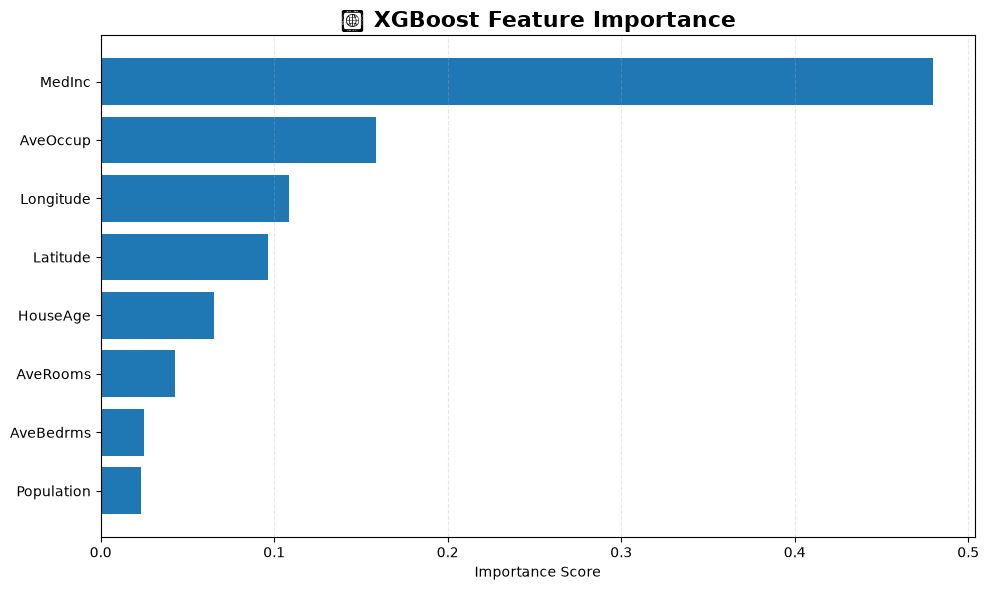

In [18]:
importance = xgb_model.feature_importances_
features = X.columns

sorted_idx = importance.argsort()

plt.figure(figsize=(10,6))

plt.barh(features[sorted_idx], importance[sorted_idx])

plt.title("📊 XGBoost Feature Importance",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Importance Score")

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.savefig("feature_importance.png", dpi=300)

plt.show()

## Observations

- **MedInc** is the most important feature, contributing nearly half of the total feature importance. This agrees with our earlier correlation analysis, where it showed the strongest linear relationship with the target.

- **AveOccup** emerged as the second most important feature despite having a very weak linear correlation with the target. This demonstrates XGBoost's ability to capture nonlinear relationships and feature interactions that correlation analysis cannot detect.

- **Longitude** and **Latitude** are also important predictors, indicating that geographical location plays a significant role in determining house prices.

- **Population**, **AveBedrms**, and **AveRooms** contributed relatively less to the model's predictions.

- The feature importance analysis confirms that XGBoost is able to learn complex relationships among features rather than relying only on individual linear correlations.

> **Note:** Feature importance should not be confused with correlation coefficients. Correlation measures the strength of a linear relationship between a feature and the target, whereas feature importance measures how useful a feature is for the predictive model. Consequently, features with low correlation may still have high importance in tree-based models due to nonlinear interactions.

In [2]:
import joblib


In [24]:
joblib.dump(
    xgb_model,
    r"C:\Users\DELL\OneDrive\Documents\ML-Projects\house_price_prediction\models\xgboost_model.pkl"
)

['C:\\Users\\DELL\\OneDrive\\Documents\\ML-Projects\\house_price_prediction\\models\\xgboost_model.pkl']

In [22]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\DELL\OneDrive\Documents\ML-Projects\house_price_prediction\notebooks
['01_EDA.ipynb']
